In [ ]:
from torchvision import transforms, utils
from torchvision.utils import save_image
from torchvision.utils import make_grid
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
import torch.nn.functional as F
from random import randint
import torch.nn as nn
from utils import Config, create_ckpt_dir, save_ckpt, load_ckpt, to_items
from PIL import Image

from glob import glob
import oyaml as yaml
import numpy as np
import datetime
import random
import torch
from pconv import PConvLayer, PartialConvolution
from loss import InpaintingLoss, VGG16FeatureExtractor
import matplotlib.pyplot as plt
import os
import cv2

In [2]:
from trainer import Trainer
from pconv_u_net import PConvUNet
from dataset import InitDataset, MaskGenerator

In [35]:
def scale_down():
    # Scale down the image
    # Load the image
    paths= glob('data_new/train/*.jpg')
    
    for path in paths:
        img = Image.open(path)
        # Resize the image
        img = img.resize((64, 64))
        # Save the image
        new_path = path.replace('data_new/train/', 'data_lr/train/')
        img.save(new_path)

    test_paths = glob('data_new/test/*.jpg')
    for path in test_paths:
        img = Image.open(path)
        # Resize the image
        img = img.resize((64, 64))
        # Save the image
        new_path = path.replace('data_new/test/', 'data_lr/test/')
        img.save(new_path)
        

In [36]:
scale_down()

In [69]:
class InitDataset(Dataset):
    def __init__(self, data_root, img_transform, mask_transform, data='train'):
        super(InitDataset, self).__init__()
        self.img_transform = img_transform
        self.mask_transform = mask_transform

        if data == 'train':
            self.paths = glob('{}/train/**/*.jpg'.format(data_root),
                              recursive=True)
            self.mask_paths = glob('{}/mask/*.png'.format(data_root))
        else:
            self.paths = glob('{}/test/*.jpg'.format(data_root, data))
            self.mask_paths = glob('{}/mask/*.png'.format(data_root))

        self.N_mask = len(self.mask_paths)

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, index):
        img = self._load_img(self.paths[index])
        img = self.img_transform(img.convert('RGB'))
        mask = Image.open(self.mask_paths[random.randint(0, self.N_mask - 1)])
        mask = self.mask_transform(mask.convert('RGB'))
        return img * mask, mask, img

    def _load_img(self, path):
        """
        For dealing with the error of loading image which is occured by the loaded image has no data.
        """
        try:
            img = Image.open(path)
        except:
            extension = path.split('.')[-1]
            for i in range(10):
                new_path = path.split('.')[0][:-1] + str(i) + '.' + extension
                try:
                    img = Image.open(new_path)
                    break
                except:
                    continue
        return img


In [70]:
def generate_mask(K=4,C=3,H=128,W=128):
    KH, KW = K * H, K * W
    offset = K // 2

    
    mask = torch.zeros((C, KH, KW), dtype=torch.uint8, device='cuda' if torch.cuda.is_available() else 'cpu')

    for x in range(H):
        for y in range(W):
            new_x = K * x + offset
            new_y = K * y + offset
            if new_x < KH and new_y < KW:
                
                mask[:, new_x, new_y] = 1

    return mask

my_mask = generate_mask(K=4)
my_mask = my_mask.permute(1, 2, 0).cpu().numpy()  # Convert from (C, H, W) → (H, W, C)

# Save
cv2.imwrite('./data_lr/mask/0.png', my_mask * 255)  # Multiply by 255 to make 1s visible as white

True

In [ ]:
img_tf= transforms.Compose([
    transforms.ToTensor(),
    
])
mask_tf= transforms.Compose([
    transforms.ToTensor(),
])
config
print("Loading the Validation Dataset...")
dataset_val = InitDataset(config.data_root,
                      img_tf,
                      mask_tf,
                      data="test")

print("Loading the Training Dataset...")
dataset_train = InitDataset(config.data_root,
                        img_tf,
                        mask_tf,
                        data="train")

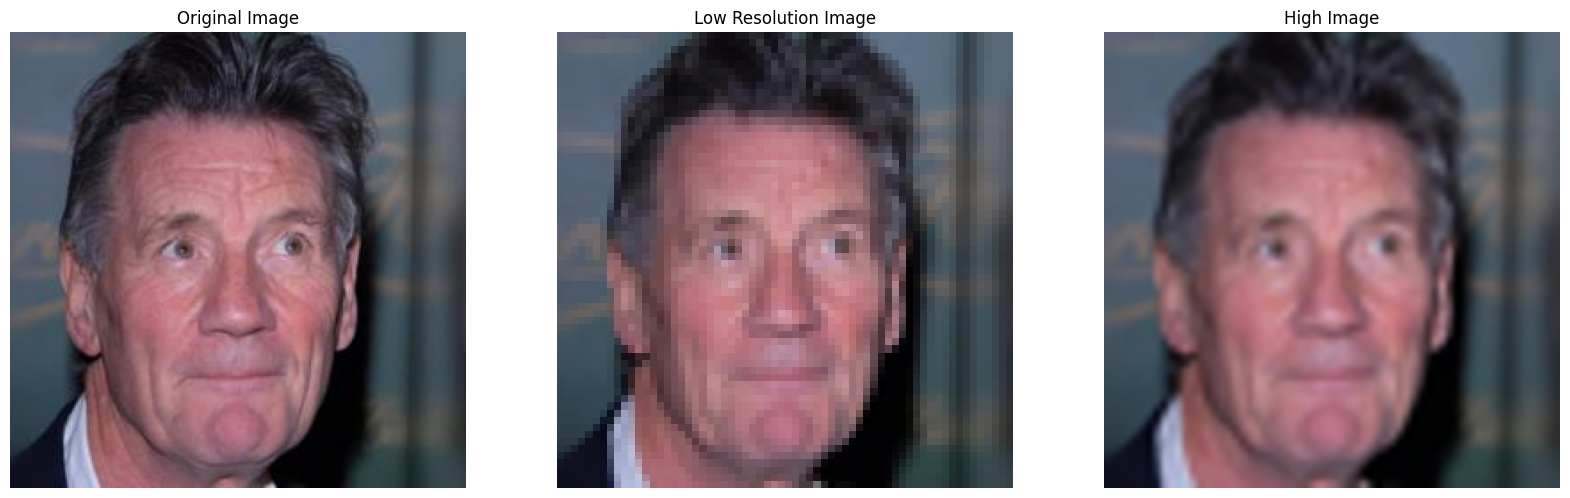

In [24]:

#figsize
plt.figure(figsize=(20, 10))
plt.subplot(1, 3, 1)
plt.title('Original Image')
plt.axis('off')
image = Image.open('data_new/train/03001.jpg')
plt.imshow(image)
plt.subplot(1, 3, 2)
plt.title('Low Resolution Image')
plt.axis('off')

image = image.resize((64, 64))

plt.imshow(image)
plt.subplot(1, 3, 3)
plt.title('High Image')
plt.axis('off')
image=image.resize((256, 256))
plt.imshow(image)
plt.show()

In [ ]:
def generate_resolution_masks():
    

In [ ]:
img_tf = transforms.Compose([
            transforms.ToTensor()
            ])

mask_tf = transforms.Compose([
            transforms.RandomResizedCrop(256),
            transforms.ToTensor()
            ])

data = InitDataset('./data_new', img_tf, mask_tf)
# print(data.__len__())
corrupted_img, mask, original_img = data[0]

corrupted_img_np = corrupted_img.permute(1, 2, 0).numpy()
original_img_np = original_img.permute(1, 2, 0).numpy()
mask_np = mask.permute(1, 2, 0).numpy()
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].imshow(original_img_np)
axs[0].set_title("Original Image")
axs[0].axis("off")

axs[1].imshow(mask_np)
axs[1].set_title("Mask")
axs[1].axis("off")

axs[2].imshow(corrupted_img_np)
axs[2].set_title("Corrupted (Input * Mask)")
axs[2].axis("off")

plt.tight_layout()
plt.show()

SyntaxError: invalid syntax (1947533877.py, line 12)

In [7]:
config = Config("./config.yml")
ckpt_dir = "./ckpt2"
if not os.path.exists(ckpt_dir):
    os.mkdir(ckpt_dir)
    os.mkdir(os.path.join(ckpt_dir, "val_vis"))
    os.mkdir(os.path.join(ckpt_dir, "models"))
config.ckpt = ckpt_dir
print("Check Point is '{}'".format(config.ckpt))

Check Point is './ckpt2'


In [8]:
# Data Transformation
img_tf = transforms.Compose([
            transforms.ToTensor()
            ])

mask_tf = transforms.Compose([
            transforms.RandomResizedCrop(256),
            transforms.ToTensor()
            ])


print("Loading the Validation Dataset...")
dataset_val = InitDataset(config.data_root,
                      img_tf,
                      mask_tf,
                      data="test")

print("Loading the Training Dataset...")
dataset_train = InitDataset(config.data_root,
                        img_tf,
                        mask_tf,
                        data="train")

Loading the Validation Dataset...
Loading the Training Dataset...
